In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
xls = pd.ExcelFile("glass.xlsx")
xls.sheet_names

['Description', 'glass']

In [4]:
df = pd.read_excel("glass.xlsx", sheet_name = "glass")

## 1. Exploratory Data Analysis (EDA):

In [5]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [6]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [9]:
# check missing values
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

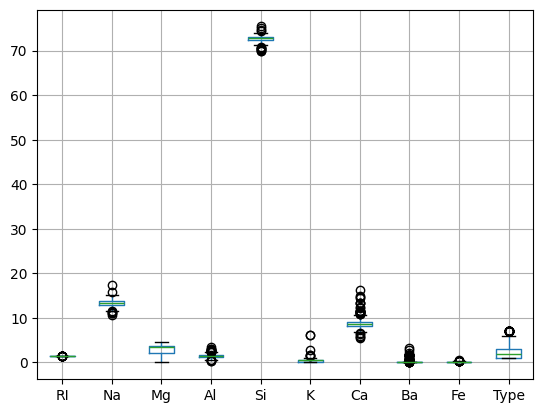

In [11]:
# check for outliers - boxplot
df.boxplot()
plt.show()

In [13]:
# handle outliers:

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Treat (cap) outliers
    df[col] = df[col].clip(lower, upper)

print("Outliers detected and treated successfully.")

Outliers detected and treated successfully.


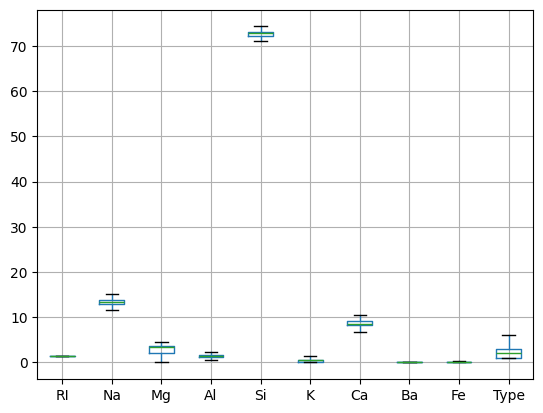

In [14]:
df.boxplot()
plt.show()

In [15]:
# check for duplicate:
df.duplicated().sum()

np.int64(1)

In [16]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
209    False
210    False
211    False
212    False
213    False
Length: 214, dtype: bool

In [17]:
df.drop_duplicates(inplace = True)

In [18]:
df.duplicated().sum()

np.int64(0)

## 2: Data Visualization:

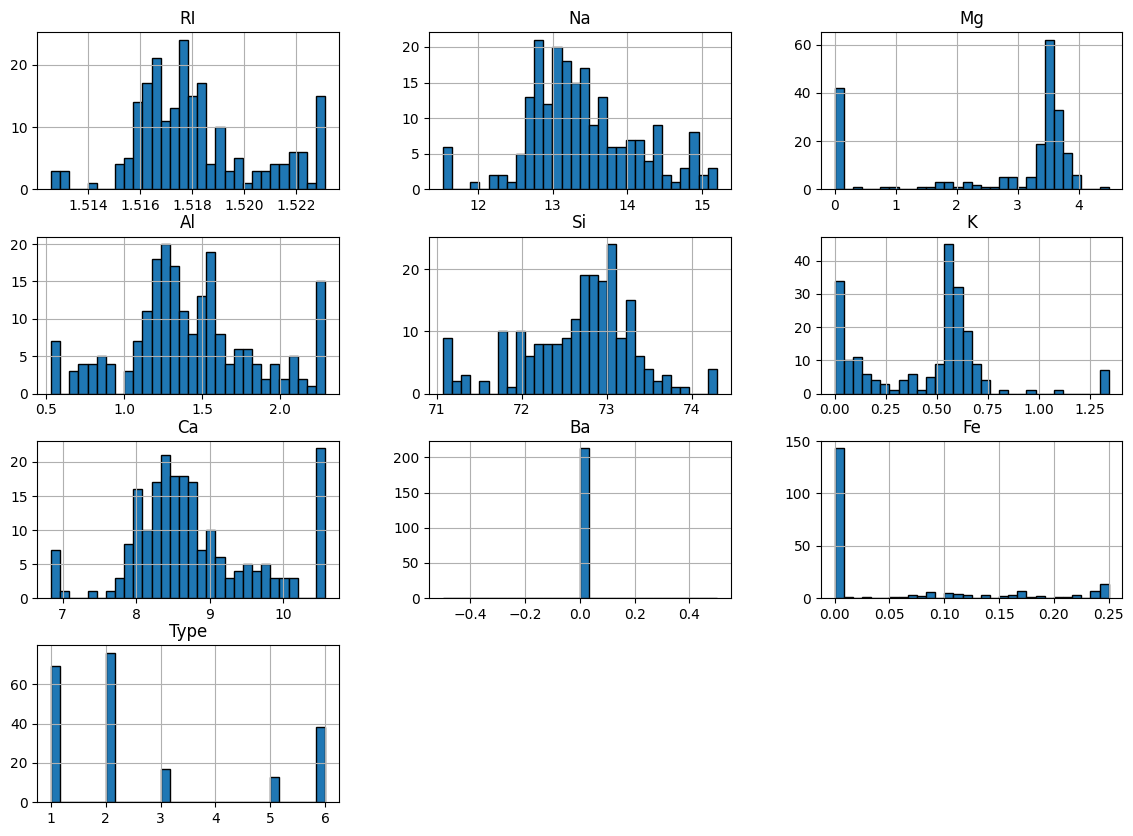

In [23]:
# histogram
df.hist(bins = 30 , edgecolor = 'black', figsize = (14,10))
plt.show()

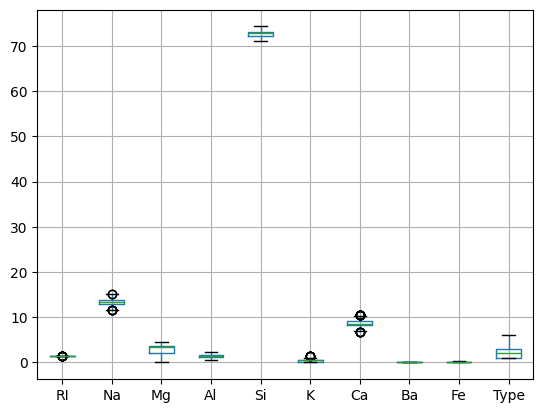

In [24]:
# boxplot
df.boxplot()
plt.show()

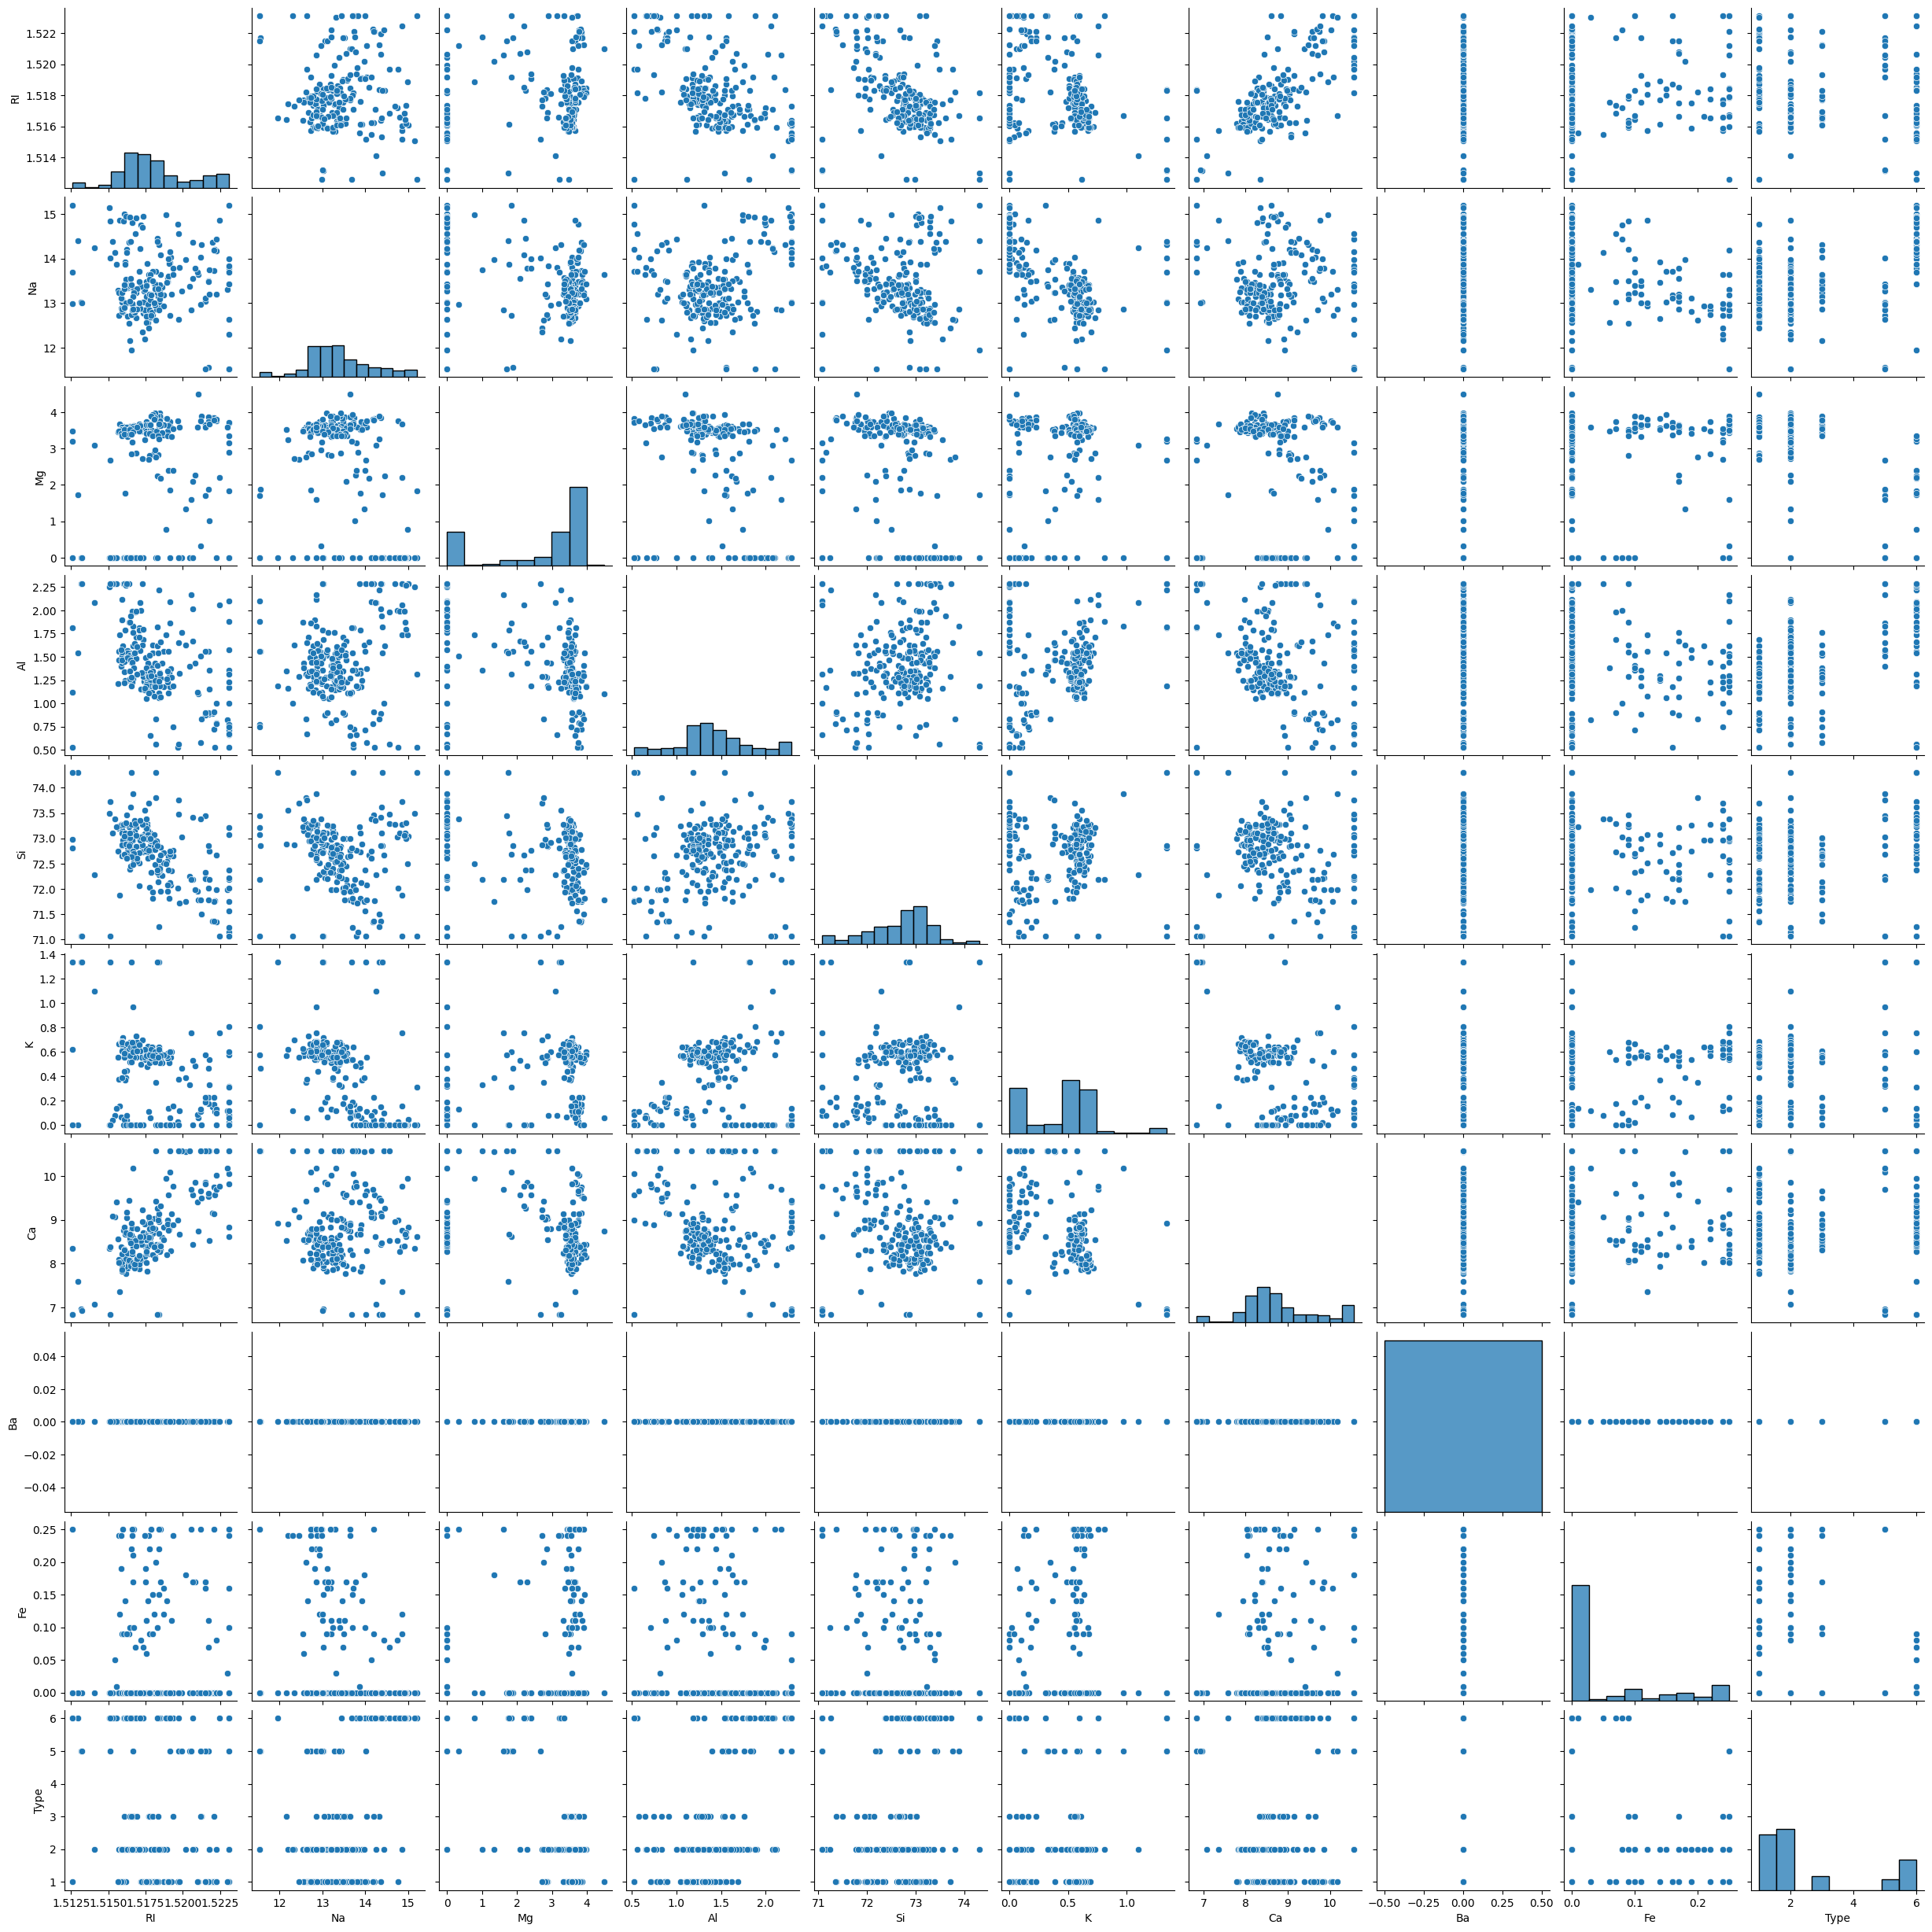

In [26]:
# pairplot
sns.pairplot(data= df)
plt.show()

In [27]:
df.corr()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.073271,-0.039240,-0.461690,-0.527154,-0.339611,0.759889,NaN,0.100235,-0.154977
Na,-0.073271,1.000000,-0.300473,0.222529,-0.158835,-0.490592,-0.107415,NaN,-0.249135,0.503755
Mg,-0.039240,-0.300473,1.000000,-0.472330,-0.206681,0.332027,-0.375568,NaN,0.104381,-0.739870
Al,-0.461690,0.222529,-0.472330,1.000000,0.131125,0.174972,-0.276127,NaN,-0.096567,0.585616
Si,-0.527154,-0.158835,-0.206681,0.131125,1.000000,-0.041506,-0.187644,NaN,-0.068527,0.166381
K,-0.339611,-0.490592,0.332027,0.174972,-0.041506,1.000000,-0.496808,NaN,0.075500,-0.240647
Ca,0.759889,-0.107415,-0.375568,-0.276127,-0.187644,-0.496808,1.000000,NaN,0.106326,0.073202
Ba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe,0.100235,-0.249135,0.104381,-0.096567,-0.068527,0.075500,0.106326,NaN,1.000000,-0.219217
Type,-0.154977,0.503755,-0.739870,0.585616,0.166381,-0.240647,0.073202,NaN,-0.219217,1.000000


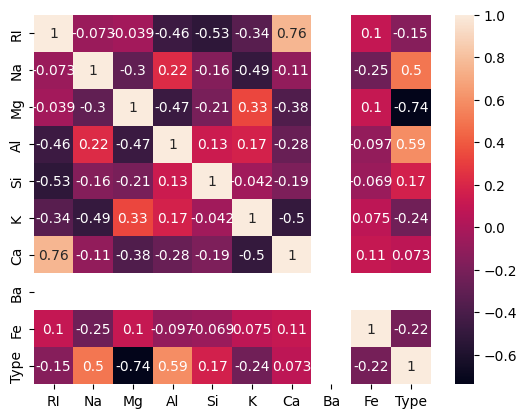

In [28]:
sns.heatmap(df.corr(), annot = True)
plt.show()

The pair plot and heatmap clearly indicate that chemical composition features such as Si, Na, Ca, and Mg play an important role in distinguishing different types of glass. Therefore, these features will be valuable for classification using Decision Trees.

## 3: Data Preprocessing

In [29]:
# no missing values
# there is no categorical variables so no encoding

In [31]:
# standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('Type', errors='ignore')
df[num_cols] = scaler.fit_transform(df[num_cols])

## 4: Random Forest Model Implementation

In [39]:
# selection of traget and predictor

y = df['Type']
X = df.drop('Type', axis = 1)

In [40]:
# 1. Divide the data into train and test split.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [48]:
#  Implement Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

rand_for=RandomForestClassifier(n_estimators=100,max_depth=3,max_features='sqrt',bootstrap=True,criterion='gini')

In [49]:
# train the model
rand_for.fit(X_train,y_train)

RandomForestClassifier(max_depth=3)

In [50]:
# trained model to predict
y_pred=rand_for.predict(X_test)

In [51]:
# Evaluate the performance on test data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy=accuracy_score(y_test,y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

Accuracy: 0.767
Precision: 0.726
Recall: 0.767
F1 Score: 0.74


## 5: Bagging and Boosting Methods

In [54]:
# Apply the Bagging and Boosting methods
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier

# Bagging Model
bagging_model = BaggingClassifier(estimator=RandomForestClassifier(n_estimators=100, random_state=42),n_estimators=10,random_state=42)


In [55]:
# train the bagging model
bagging_model.fit(X_train, y_train)

BaggingClassifier(estimator=RandomForestClassifier(random_state=42),
                  random_state=42)

In [56]:
# trained model to predict
y_pred_bag = bagging_model.predict(X_test)

In [58]:
# Evaluate the bagging model
accuracy_bag = accuracy_score(y_test, y_pred_bag)
precision_bag = precision_score(y_test, y_pred_bag, average='weighted')
recall_bag = recall_score(y_test, y_pred_bag, average='weighted')
f1_bag = f1_score(y_test, y_pred_bag, average='weighted')
print(f"Accuracy: {accuracy_bag:.3f}, Precision: {precision_bag:.3f}, Recall: {recall_bag:.3f}, F1-score: {f1_bag:.3f}")

Accuracy: 0.837, Precision: 0.844, Recall: 0.837, F1-score: 0.835


In [59]:
# Create Boosting model
boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)


In [60]:
# train the boosting model
boosting_model.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

In [61]:
# trained model to predict
y_pred_boost = boosting_model.predict(X_test)

In [63]:
# Evaluate the boosting model
accuracy_boost = accuracy_score(y_test, y_pred_boost)
precision_boost = precision_score(y_test, y_pred_boost, average='weighted')
recall_boost = recall_score(y_test, y_pred_boost, average='weighted')
f1_boost = f1_score(y_test, y_pred_boost, average='weighted')
print(f"Accuracy: {accuracy_boost:.3f}, Precision: {precision_boost:.3f}, Recall: {recall_boost:.3f}, F1-score: {f1_boost:.3f}")

Accuracy: 0.791, Precision: 0.793, Recall: 0.791, F1-score: 0.787


##  Additional Notes:

1. Explain Bagging and Boosting methods. How is it different from each other.

   Bagging is an ensemble method which built on multiple independent models and then combines their predictions usually by majority voting or averaging.
       * bagging reduce variance.
       * base models are strong learners.
       * faster.

   Boosting is an ensemble method that build models sequentially , where new model tries to correct the errors of the previous models.
       * reduce bias and improve accuracy.
       * usually for weak learners.
       * And it is slower.

2.Explain how to handle imbalance in the data.

    1.Ensemble methods can be used , with algorithmic approaches like XGBoost or LightGBM.
    2.can use class weights .
    3.undersampling where they randomly remove samples from majority class.
    4.Oversampling like random oversampling and SMOTE.

-in random oversampling they duplicate existing minority class samples
-in SMOTE they create synthetic samples by interpolating between minority class 